In [506]:
import os
from dotenv import load_dotenv

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

from statsmodels.tsa.stattools import adfuller, coint
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime, timezone

load_dotenv()

True

In [507]:
# os.getenv("BNB_KEY")

tickers = ['ETHEUR', 'BNBEUR']
interval = "1d"
start = datetime(2022, 1, 1)
end = datetime(2026, 1, 27)

url = "https://api.binance.com/api/v3/klines"

columns = [
    "open_time",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "close_time",
    "quote_volume",
    "num_trades",
    "taker_base_volume",
    "taker_quote_volume",
    "ignore"
]

data = pd.DataFrame()

In [508]:
for ticker in tickers:
    params = {
        "symbol": ticker,
        "interval": interval,
        "startTime": int(start.timestamp() * 1000),
        "endTime": int(end.timestamp() * 1000),
    }
    res = requests.get(url, params)
    if res.status_code == 200:
        
        df = pd.DataFrame(res.json(), columns=columns)
        df['time'] = pd.to_datetime(df['open_time'], unit = 'ms', utc = True)
        df['close'] = pd.to_numeric(df['close'], errors = 'raise')

        data[f'{ticker}_time'] = df['time']
        data[f'{ticker}_px'] = df['close']

<h5 style="color:red"> PRACTICE THE DATA CLEANING CHAPTER </h5>

In [509]:
data

,ETHEUR_time,ETHEUR_px,BNBEUR_time,BNBEUR_px
0,2022-01-02 00:00:00+00:00,3370.05,2022-01-02 00:00:00+00:00,467.5
1,2022-01-03 00:00:00+00:00,3332.50,2022-01-03 00:00:00+00:00,452.9
2,2022-01-04 00:00:00+00:00,3356.89,2022-01-04 00:00:00+00:00,449.9
3,2022-01-05 00:00:00+00:00,3135.67,2022-01-05 00:00:00+00:00,420.0
4,2022-01-06 00:00:00+00:00,3019.23,2022-01-06 00:00:00+00:00,418.8
...,...,...,...,...
495,2023-05-12 00:00:00+00:00,1668.88,2023-05-12 00:00:00+00:00,284.8
496,2023-05-13 00:00:00+00:00,1662.91,2023-05-13 00:00:00+00:00,287.8
497,2023-05-14 00:00:00+00:00,1664.22,2023-05-14 00:00:00+00:00,288.6
498,2023-05-15 00:00:00+00:00,1676.03,2023-05-15 00:00:00+00:00,289.4


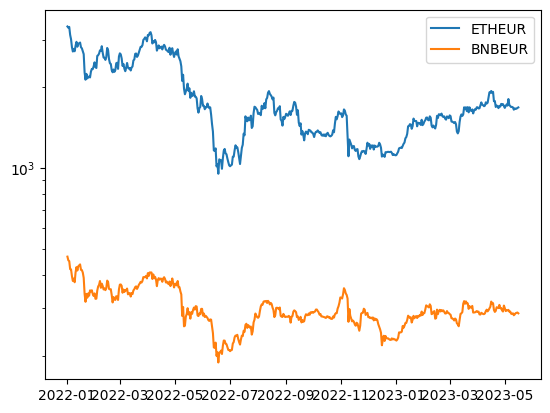

In [510]:
for ticker in tickers:
    plt.plot(data[f'{ticker}_time'], data[f'{ticker}_px'], label = f'{ticker}')

plt.yscale('log')
plt.legend()

In [511]:
x = data["ETHEUR_px"]
y = data["BNBEUR_px"]

stat, pval, crit = coint(y, x, trend = 'c', maxlag = 1, autolag = None)

print("Engle–Granger CADF via coint")
print("stat:", stat)
print("p-value:", pval)
print("crit:", crit)

Engle–Granger CADF via coint
stat: -3.773287027131317
p-value: 0.014708410293044668
crit: [-3.91852234 -3.34840209 -3.05296032]


In [512]:
X = sm.add_constant(x)
model = sm.OLS(y, X)
reg = model.fit()
hedge_ratio = reg.params[1]
hedge_ratio

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_71719/1667605926.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hedge_ratio = reg.params[1]


np.float64(0.07983430191136096)

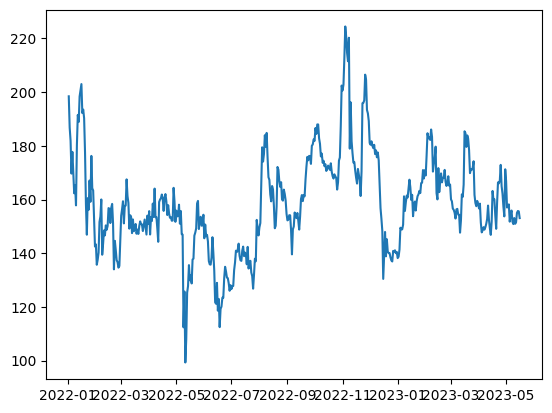

In [27]:
spread = y - hedge_ratio * x # stationary residuals

plt.plot(data['BNBEUR_time'], spread)

In [37]:
tstat, pval, _, _, crit, _ = adfuller(spread)

pval, tstat, crit

(np.float64(0.0015014743476794651),
 np.float64(-3.983129183653897),
 {'1%': np.float64(-3.4435761493506294),
  '5%': np.float64(-2.867372960189225),
  '10%': np.float64(-2.5698767442886696)})

In [38]:
y2 = np.column_stack([y, x])

jres = coint_johansen(y2, 0, 1)

print("Trace statistics:", jres.trace_stat)
print("Trace crit values (90, 95, 99%):\n", jres.trace_stat_crit_vals)

print("Max-eig statistics:", jres.max_eig_stat)
print("Max-eig crit values (90, 95, 99%):\n", jres.max_eig_stat_crit_vals)

Trace statistics: [21.78350709  5.1820186 ]
Trace crit values (90, 95, 99%):
 [[13.4294 15.4943 19.9349]
 [ 2.7055  3.8415  6.6349]]
Max-eig statistics: [16.60148849  5.1820186 ]
Max-eig crit values (90, 95, 99%):
 [[12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


In [40]:
print("Eigenvalues:")
print(jres.eig)

print('Eigenvectors:')
print(jres.evec)

beta = jres.evec[:, 0]

Eigenvalues:
[0.03278679 0.01035171]
Eigenvectors:
[[ 0.04983573 -0.02498959]
 [-0.00317972  0.00354209]]


In [565]:
tmp = beta[1] / beta[0]
tmp

/var/folders/bc/hnzwjdn546lcc572zg36k_vc0000gn/T/ipykernel_71719/2752279575.py:1: RuntimeWarning: invalid value encountered in divide
  tmp = beta[1] / beta[0]


array([       nan, 0.00030008, 0.00030014, 0.0003001 , 0.00030244,
       0.00030395, 0.0003034 , 0.00030339, 0.00030212, 0.00029895,
       0.00029819, 0.00030078, 0.00030021, 0.00030026, 0.0003003 ,
       0.00029866, 0.00029947, 0.00030032, 0.00029548, 0.00032074,
       0.00031679, 0.00031092, 0.00031387, 0.0003153 , 0.00031367,
       0.00032639, 0.00035387, 0.00035628, 0.00035345, 0.00036267,
       0.00036714, 0.00036399, 0.00036533, 0.00041223, 0.00040918,
       0.0004092 , 0.0004071 , 0.00040601, 0.00040838, 0.00043273,
       0.00043989, 0.00043975, 0.00044049, 0.00044349, 0.00046268,
       0.00046449, 0.00048492, 0.000503  , 0.00050307, 0.00050622,
       0.0004909 , 0.00047796, 0.0004774 , 0.00048453, 0.00052248,
       0.00052415, 0.00054962, 0.00058997, 0.00057884, 0.00057869,
       0.00059242, 0.00059928, 0.00059241, 0.00060828, 0.000624  ,
       0.00065661, 0.00069229, 0.00068403, 0.00068427, 0.00068621,
       0.00068309, 0.00067917, 0.00068809, 0.00072577, 0.00072

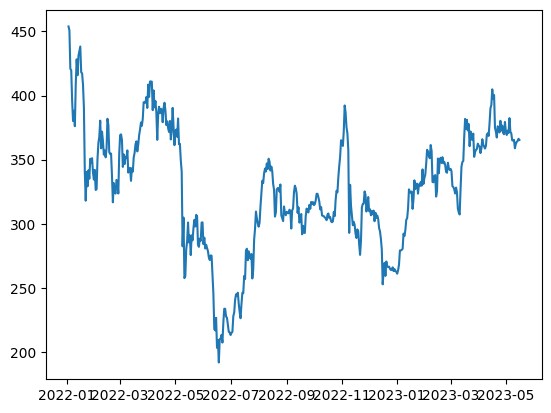

In [566]:
tmp_spread = y + x * tmp

plt.plot(data['BNBEUR_time'], tmp_spread)

In [54]:
yport = y2 @ beta
yport = pd.Series(yport, index = data['BNBEUR_time'])
yport

BNBEUR_time
2022-01-02 00:00:00+00:00    12.582391
2022-01-03 00:00:00+00:00    11.974188
2022-01-04 00:00:00+00:00    11.747127
2022-01-05 00:00:00+00:00    10.960457
2022-01-06 00:00:00+00:00    11.270900
                               ...    
2023-05-12 00:00:00+00:00     8.886646
2023-05-13 00:00:00+00:00     9.055136
2023-05-14 00:00:00+00:00     9.090839
2023-05-15 00:00:00+00:00     9.093156
2023-05-16 00:00:00+00:00     8.973484
Length: 500, dtype: float64

#### Determine hedge ratio and half-life

In [223]:
yport_lag = yport.shift()
deltaY = yport - yport_lag

yport_lag = yport_lag[1:]
deltaY = deltaY[1:]

x = sm.add_constant(yport_lag)
model = sm.OLS(deltaY, x).fit()

port_beta = model.params.iloc[1]
half_life = -np.log(2) / port_beta
port_beta, half_life

(np.float64(-0.07033984567529314), np.float64(9.854260752286711))

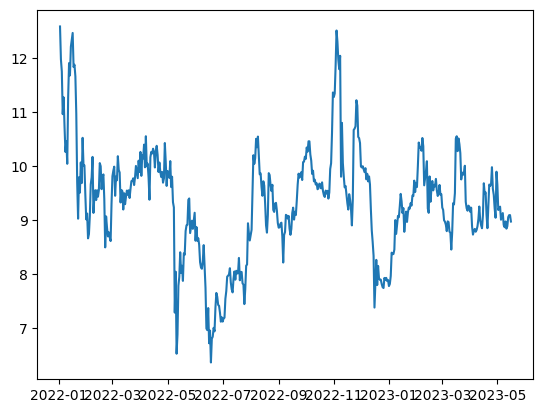

In [516]:
plt.plot(yport)

In [79]:
loockback = round(half_life)
ma = yport.rolling(loockback, loockback).mean()
msd = yport.rolling(loockback, loockback).std()
zscore = (yport - ma) / msd
zscore

BNBEUR_time
2022-01-02 00:00:00+00:00         NaN
2022-01-03 00:00:00+00:00         NaN
2022-01-04 00:00:00+00:00         NaN
2022-01-05 00:00:00+00:00         NaN
2022-01-06 00:00:00+00:00         NaN
                               ...   
2023-05-12 00:00:00+00:00   -0.881956
2023-05-13 00:00:00+00:00    0.426386
2023-05-14 00:00:00+00:00    1.040094
2023-05-15 00:00:00+00:00    0.929063
2023-05-16 00:00:00+00:00   -0.087228
Length: 500, dtype: float64

#### Strategy 1

This is the most basic and reliable strategy because has no data-snooping (no parameters to optimise). It is highly statsitical significant because it
continously trades the market (but also makes it impractical for that same reason: inifinitesimal amounts being traded)

(0          NaN
 1          NaN
 2          NaN
 3          NaN
 4          NaN
 5          NaN
 6          NaN
 7          NaN
 8          NaN
 9          NaN
 10   -0.021565
 11    0.007433
 12   -0.017865
 13   -0.004321
 14   -0.003979
 dtype: float64,
 <Axes: >)

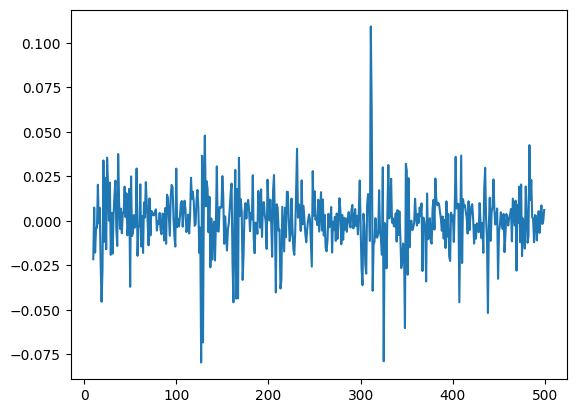

In [251]:
units = -zscore
units = units.values
units = units.reshape(-1, 1)

prices = data[[f'{ticker}_px' for ticker in reversed(tickers)]]
chnges = prices.pct_change()

positions = beta * y2 * units
positions = pd.DataFrame(positions, columns = prices.columns)

# y2[:5], components[:5], components[:5].pct_change(), (components[:5] - components[:5].shift()) / components[:5].shift()

pnl = (positions.shift() * chnges).sum(axis = 1)
ret = pnl / (np.abs(positions.shift())).sum(axis = 1)

ret[:15], ret.plot()

(10   -0.021565
 11   -0.014292
 12   -0.031901
 13   -0.036084
 14   -0.039920
 15   -0.020464
 16   -0.021903
 17   -0.014759
 18   -0.038211
 19   -0.081927
 20   -0.107632
 21   -0.077390
 22   -0.088285
 23   -0.066337
 24   -0.081270
 dtype: float64,
 [<matplotlib.lines.Line2D at 0x15067fd90>])

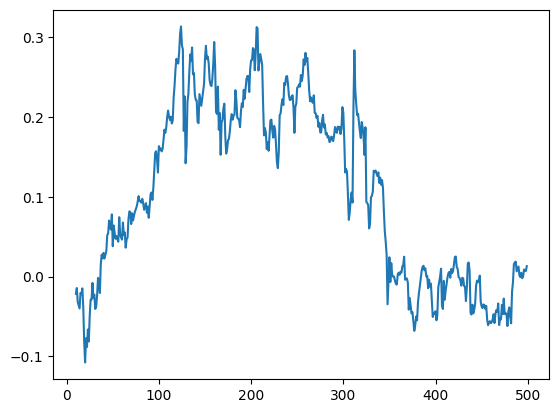

In [212]:
ret = ret[~np.isnan(ret)]

cum = np.cumprod(1 + ret) - 1

cum[:15], plt.plot(cum)

In [221]:
ret = ret[~np.isnan(ret)]

APR = np.prod(1 + ret) ** (252 / len(ret)) - 1

SR = (ret.mean() / ret.std()) * np.sqrt(252)

print(f'APR: {APR:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: 0.0067
Sharpe: 0.1605


### Comparing Price Spread, Log Price Spread and Ratio

<h5 style="color:red"> COMPLETE EXPERIMENT </h5>

In [596]:
lookback = 20 # this should be chosen in hindsight - and is for research only

T = len(data)
h_ratios = np.full((T, 1), np.nan)

for i in range(lookback, T + 1):
    yn = y[i - lookback: i]
    xn = x[i - lookback: i]
    xn = sm.add_constant(xn)
    model = sm.OLS(yn, xn).fit()
    h_ratios[i - 1] = model.params['ETHEUR_px']

yport = np.column_stack([np.ones_like(h_ratios), -h_ratios])
yport = np.sum(yport * y2, axis = 1)

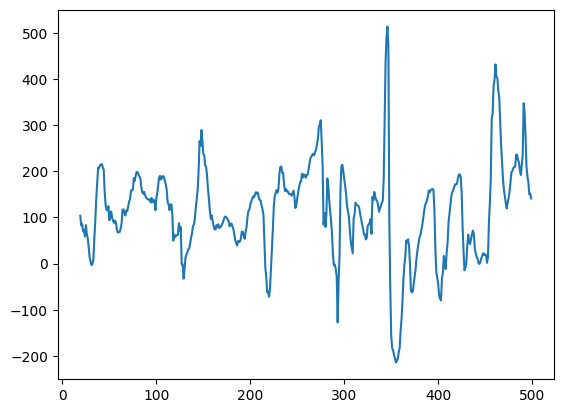

In [597]:
plt.plot(yport)

In [598]:
ma = pd.Series(yport).rolling(lookback).mean()
st = pd.Series(yport).rolling(lookback).std()

zscore = (yport - ma) / st

#### Strategy 2

If we set the look-back to a short period, and small `entryZscore` and `exitZscore` magnitude, we will get a shorter holding period and more
round trip trades and generally higher profits.

In [614]:
entry_zscore = 1
exit_zscore = 0

long_entry = zscore < -entry_zscore
long_exit = zscore >= -exit_zscore

short_entry = zscore > entry_zscore
short_exit = zscore <= exit_zscore

units_long = np.full(len(y2), np.nan)
units_short = np.full(len(y2), np.nan)

units_long[0] = 0
units_short[0] = 0

units_long[long_entry] = 1
units_long[short_entry] = 0

units_short[short_entry] = -1
units_short[short_exit] = 0

def ffill(arr):
    arr = arr.copy()
    mask = np.isnan(arr)
    idx = np.where(~mask, np.arange(len(arr)), 0)
    np.maximum.accumulate(idx, out=idx)
    return arr[idx]

units_long = ffill(units_long)
units_short = ffill(units_short)

units = units_long + units_short
units = units.reshape(-1, 1)


units = np.tile(units, (1, y2.shape[1]))
param = np.column_stack([np.ones_like(h_ratios), -h_ratios])

prices = data[[f'{ticker}_px' for ticker in reversed(tickers)]]
chnges = prices.pct_change()


positions = units * param * y2
positions = pd.DataFrame(positions, columns = prices.columns)

# # y2[:5], components[:5], components[:5].pct_change(), (components[:5] - components[:5].shift()) / components[:5].shift()

pnl = (positions.shift() * chnges).sum(axis = 1)
ret = pnl / (np.abs(positions.shift())).sum(axis = 1)

(39   -0.002838
 40    0.005321
 41   -0.001928
 42    0.003634
 43   -0.002755
 44   -0.025134
 45   -0.023097
 46   -0.014611
 47   -0.025669
 55   -0.029454
 56   -0.024398
 57   -0.015705
 58   -0.003654
 59    0.001043
 60    0.010037
 dtype: float64,
 [<matplotlib.lines.Line2D at 0x157e760d0>])

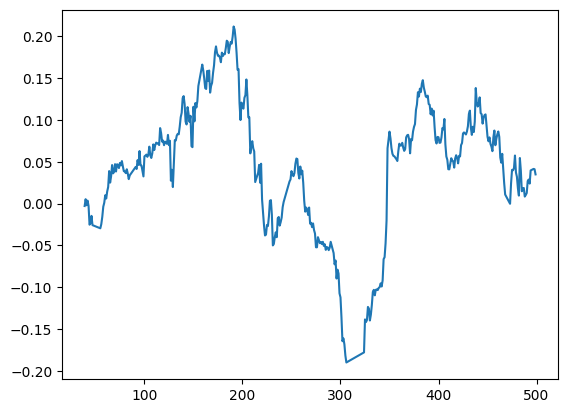

In [615]:
ret = ret[~np.isnan(ret)]

cum = np.cumprod(1 + ret) - 1

cum[:15], plt.plot(cum)

In [619]:
ret_clean = ret[~np.isnan(ret)]

APR = np.prod(1 + ret_clean) ** (252 / len(ret_clean)) - 1

APR_simple = 252 * ret_clean.mean()

SR = (ret_clean.mean() / ret_clean.std()) * np.sqrt(252)

print(f'APR: {APR:.4f}')
print(f'Simple APR: {APR_simple:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: 0.0212
Simple APR: 0.0417
Sharpe: 0.2041


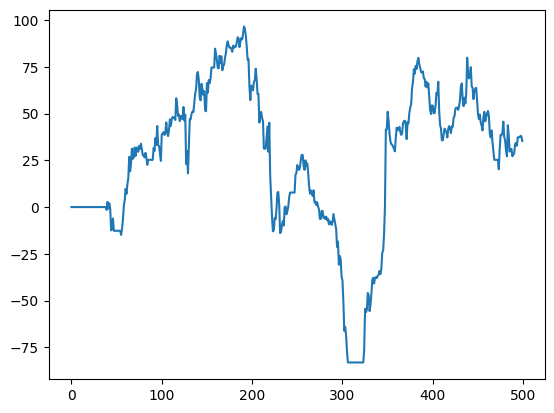

In [617]:
equity = (1 + ret.fillna(0.0)).cumprod()
PnL_cum = pnl.fillna(0.0).cumsum()

# plt.plot(equity.index, equity.values)
plt.plot(PnL_cum.index, PnL_cum.values)

#### Strategy 3
We make use of `Kalman Filter` as a dynamic weighting scheme on new observations to paick the best hedge ratio

In [ ]:
x = data["ETHEUR_px"]

x = np.column_stack((x, np.ones_like(x)))

delta = 0.0001 # param to be optimized

yhat = np.full(len(y), np.nan)

e = np.full(len(y), np.nan)
Q = np.full(len(y), np.nan)

# for clarity denote R(t|t) by P(t)
P = np.zeros((2, 2))
beta = np.full((2, x.shape[0]), np.nan)

Vw = delta / (1 - delta) * np.diag(np.ones(2))
Ve = 0.001

# initial values
beta[:, 0] = 0
R = np.zeros((2, 2))


for t in range(len(y)):
    if t > 0:
        beta[:, t] = beta[:, t - 1] # state prediction
        R = P + Vw
    
    yhat[t] = x[t, :] @ beta[:, t]
    Q[t] = x[t, :] @ R @ x[t, :].T + Ve

    # Now we observe t
    e[t] = y[t] - yhat[t] # prediction error
    K = R @ x[t, :] / Q[t]

    beta[:, t] = beta[:, t] + K * e[t]
    
    # I = np.eye(2)
    # P = (I - np.outer(K, x[t, :])) @ R @ (I - np.outer(K, x[t, :])).T + Ve * np.outer(K, K)

    P = R - np.outer(K, x[t, :]) @ R
    # P = 0.5 * (P + P.T)


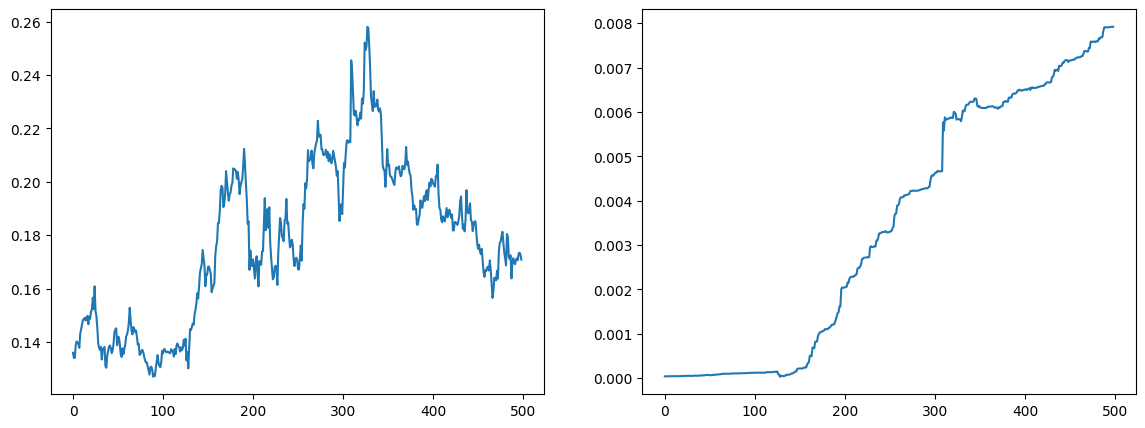

In [621]:
fig, ax = plt.subplots(1, 2, figsize = (14, 5))

ax[0].plot(beta[0, 1:])
ax[1].plot(beta[1, 1:])

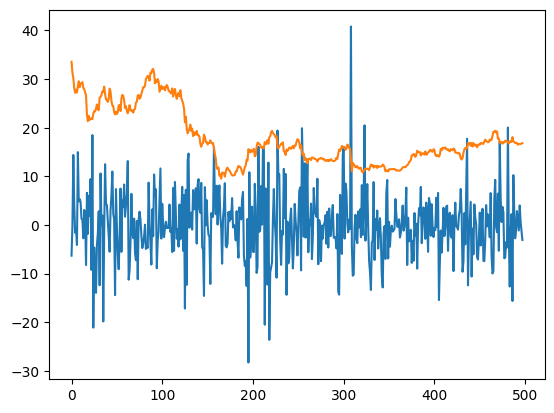

In [624]:
plt.plot(e[2:])
plt.plot(np.sqrt(Q)[2:])


In [637]:
long_entry = e < - np.sqrt(Q)
long_exit = e > - np.sqrt(Q)

short_entry = e > np.sqrt(Q)
short_exit = e < np.sqrt(Q)

units_long = np.full(len(y2), np.nan)
units_short = np.full(len(y2), np.nan)

units_long[0] = 0
units_short[0] = 0

units_long[long_entry] = 1
units_long[short_entry] = 0

units_short[short_entry] = -1
units_short[short_exit] = 0

def ffill(arr):
    arr = arr.copy()
    mask = np.isnan(arr)
    idx = np.where(~mask, np.arange(len(arr)), 0)
    np.maximum.accumulate(idx, out=idx)
    return arr[idx]

units_long = ffill(units_long)
units_short = ffill(units_short)

units = units_long + units_short
units = units.reshape(-1, 1)


units = np.tile(units, (1, y2.shape[1]))
param = np.column_stack([np.ones_like(beta[0, :]), -beta[0, :]])

prices = data[[f'{ticker}_px' for ticker in reversed(tickers)]]
chnges = prices.pct_change()


positions = units * param * y2
positions = pd.DataFrame(positions, columns = prices.columns)

# # y2[:5], components[:5], components[:5].pct_change(), (components[:5] - components[:5].shift()) / components[:5].shift()

pnl = (positions.shift() * chnges).sum(axis = 1)
ret = pnl / (np.abs(positions.shift())).sum(axis = 1)

In [638]:
ret_clean = ret[~np.isnan(ret)]

APR = np.prod(1 + ret_clean) ** (252 / len(ret_clean)) - 1

APR_simple = 252 * ret_clean.mean()

SR = (ret_clean.mean() / ret_clean.std()) * np.sqrt(252)

print(f'APR: {APR:.4f}')
print(f'Simple APR: {APR_simple:.4f}')
print(f'Sharpe: {SR:.4f}')

APR: -0.0871
Simple APR: -0.0729
Sharpe: -0.3809


Implementing Kalman filter w/ library

In [652]:
from statsmodels.tsa.statespace.kalman_filter import KalmanFilter

bnb = np.asarray(data["BNBEUR_px"])
eth = np.asarray(data["ETHEUR_px"])

y = np.asarray(bnb)
n = len(eth)

X = np.column_stack((eth, np.ones_like(eth)))

delta = 0.0001
Vw = (delta / (1 - delta)) * np.eye(2)
Ve = 0.001

kf = KalmanFilter(k_endog = 1, k_states = 2, k_posdef = 2)

design = np.zeros((1, 2, n))
design[0, 0, :] = X[:, 0]
design[0, 1, :] = X[:, 1]

kf.bind(y)
kf.design = design
kf.transition = np.eye(2)
kf.selection = np.eye(2)
kf.state_cov = Vw
kf.obs_cov = np.array([[Ve]])

kf.initialize_known(np.zeros(2), np.zeros((2, 2)))

res = kf.filter()

beta = res.filtered_state
P_filt = res.filtered_state_cov

beta_pred = res.predicted_state
beta_pred = beta_pred[:, -n:]

P_pred = res.predicted_state_cov
P_pred = P_pred[:, :, -n:]

yhat = np.einsum("ij,ji->i", X, beta_pred)

Q = np.einsum("ij,tjk,ik->i", X, P_pred.transpose(2, 0, 1), X) + Ve

# e = y - yhat
e = y[:, 0] - yhat

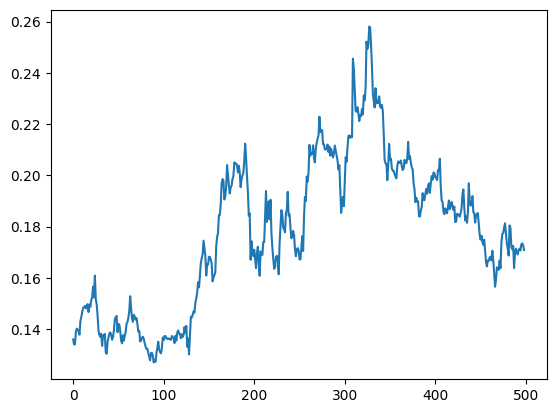

In [659]:
plt.plot(beta[0, 1:])

In [688]:
from pykalman import KalmanFilter

delta = 1e-4
Vw = delta / (1 - delta) * np.eye(2)

obs_mat = np.vstack([eth.squeeze(), np.ones_like(eth.squeeze())]).T[:, np.newaxis]

kf = KalmanFilter(
    n_dim_obs = 1,
    n_dim_state = 2,
    initial_state_mean = np.zeros(2),
    initial_state_covariance = np.ones((2, 2)),
    transition_matrices = np.eye(2),
    observation_matrices = obs_mat,
    observation_covariance = 1.0,
    transition_covariance = Vw
)

state_means, state_covs = kf.filter(bnb.squeeze())

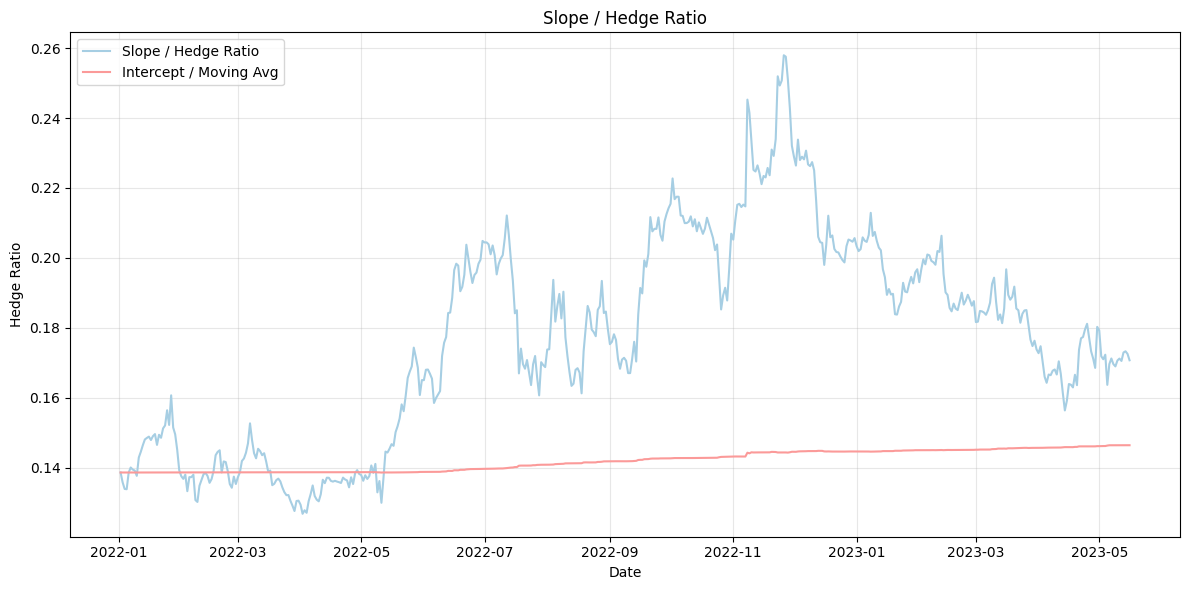

,Date,Hedge Ratio,MA
0,2022-01-02 00:00:00+00:00,0.138681,0.138681
1,2022-01-03 00:00:00+00:00,0.135865,0.138677
2,2022-01-04 00:00:00+00:00,0.133983,0.138677
3,2022-01-05 00:00:00+00:00,0.133899,0.138677
4,2022-01-06 00:00:00+00:00,0.138660,0.138679
...,...,...,...
495,2023-05-12 00:00:00+00:00,0.170568,0.146469
496,2023-05-13 00:00:00+00:00,0.172973,0.146473
497,2023-05-14 00:00:00+00:00,0.173325,0.146473
498,2023-05-15 00:00:00+00:00,0.172585,0.146474


In [695]:
state_means_temp = pd.DataFrame(np.array(state_means))
state_means_df = pd.concat([data['ETHEUR_time'].reset_index(drop=True), state_means_temp], axis=1)
state_means_df.columns = ['Date', 'Hedge Ratio', 'MA']
state_means_df['Date'] = pd.to_datetime(state_means_df['Date'])


plt.figure(figsize=(12, 6))

plt.plot(
    state_means_df['Date'],
    state_means_df['Hedge Ratio'],
    color='#A6CEE3',
    label='Slope / Hedge Ratio'
)

plt.plot(
    state_means_df['Date'],
    state_means_df['MA'],
    color='#FB9A99',
    label='Intercept / Moving Avg'
)

plt.title("Slope / Hedge Ratio")
plt.xlabel("Date")
plt.ylabel("Hedge Ratio")

plt.grid(alpha=0.3)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

state_means_df